# Laboratorio 2 - LSTM (avance)

Se retoman las dos series mensuales del laboratorio 1 (total de viajeros y viajeros por vía aérea)
y se entrenan modelos LSTM con tuneo de hiperparámetros. Framework: PyTorch (TensorFlow no tiene
build para Python 3.14).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(0)
np.random.seed(0)
BASE = Path("..")

## Datos

Se regeneran las series y el split desde `src/preparar_datos.py`.

In [2]:
%run ../src/preparar_datos.py

filas limpias: (137642, 14)
serie: 2009-01-01 - 2026-06-01
corte train/test en: 2021-04-01


In [3]:
def cargar(nombre):
    tr = pd.read_csv(BASE / f"data/processed/train_{nombre}.csv", index_col=0, parse_dates=True).iloc[:, 0]
    te = pd.read_csv(BASE / f"data/processed/test_{nombre}.csv", index_col=0, parse_dates=True).iloc[:, 0]
    return tr, te

series = {"total": cargar("total"), "aerea": cargar("aerea")}
for n, (tr, te) in series.items():
    print(n, "-> train:", len(tr), "test:", len(te))

total -> train: 147 test: 63
aerea -> train: 147 test: 63


## Preprocesamiento

Las series tienen tendencia y varianza creciente, así que se aplica `log1p` para estabilizar la
varianza y luego un escalado min-max con los valores del train. El LSTM se alimenta con ventanas
deslizantes de `lookback` meses.

In [4]:
def hacer_ventanas(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback])
    return np.array(X), np.array(y)


class LSTM(nn.Module):
    def __init__(self, hidden, layers):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

## Entrenamiento y pronóstico

Cada modelo se entrena sobre el train y luego pronostica todo el horizonte de test de forma
recursiva (usa sus propias predicciones para alimentar la siguiente). Se mide RMSE y MAE contra
el test real.

In [5]:
def entrenar_evaluar(train, test, lookback, hidden, layers, epochs=250, lr=0.01):
    tr_log = np.log1p(train.values)
    lo, hi = tr_log.min(), tr_log.max()
    escalar = lambda a: (a - lo) / (hi - lo)
    invertir = lambda a: np.expm1(a * (hi - lo) + lo)

    tr_s = escalar(tr_log)
    X, y = hacer_ventanas(tr_s, lookback)
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    torch.manual_seed(0)
    modelo = LSTM(hidden, layers)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    modelo.train()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(modelo(Xt), yt)
        loss.backward()
        opt.step()

    # pronostico recursivo sobre el horizonte de test
    modelo.eval()
    ventana = list(tr_s[-lookback:])
    preds = []
    with torch.no_grad():
        for _ in range(len(test)):
            x = torch.tensor(ventana[-lookback:], dtype=torch.float32).view(1, lookback, 1)
            p = modelo(x).item()
            preds.append(p)
            ventana.append(p)

    pred = invertir(np.array(preds))
    rmse = float(np.sqrt(np.mean((pred - test.values) ** 2)))
    mae = float(np.mean(np.abs(pred - test.values)))
    return pred, rmse, mae

## Tuneo de hiperparámetros

Se prueba una grilla de configuraciones (tamaño de ventana, neuronas ocultas y capas). Da varios
modelos LSTM por serie y permite elegir el mejor por RMSE.

In [6]:
grilla = [
    dict(lookback=12, hidden=16, layers=1),
    dict(lookback=12, hidden=32, layers=1),
    dict(lookback=12, hidden=32, layers=2),
    dict(lookback=24, hidden=32, layers=1),
    dict(lookback=24, hidden=64, layers=2),
]

resultados = {}
predicciones = {}
for nombre, (train, test) in series.items():
    filas = []
    for cfg in grilla:
        pred, rmse, mae = entrenar_evaluar(train, test, **cfg)
        filas.append({**cfg, "rmse": rmse, "mae": mae})
        predicciones[(nombre, tuple(cfg.values()))] = pred
    tabla = pd.DataFrame(filas).sort_values("rmse").reset_index(drop=True)
    resultados[nombre] = tabla
    print(f"\n=== serie {nombre} ===")
    print(tabla.to_string(index=False))


=== serie total ===
 lookback  hidden  layers          rmse          mae
       12      32       2  79606.326429 69607.355912
       24      64       2  80292.480988 70144.106343
       24      32       1  88652.549059 78514.451791
       12      32       1  94721.789307 84725.747444
       12      16       1 104946.746081 93323.535474



=== serie aerea ===
 lookback  hidden  layers         rmse          mae
       24      64       2 27926.469705 23039.340642
       12      16       1 28961.834404 24051.180354
       12      32       1 31487.400724 26459.330701
       24      32       1 34236.616026 28991.251440
       12      32       2 44276.828785 37247.551418


### Mejor modelo por serie

In [7]:
mejores = {}
for nombre, tabla in resultados.items():
    best = tabla.iloc[0]
    mejores[nombre] = best
    print(f"{nombre}: lookback={int(best.lookback)} hidden={int(best.hidden)} "
          f"layers={int(best.layers)} -> RMSE={best.rmse:.1f} MAE={best.mae:.1f}")

total: lookback=12 hidden=32 layers=2 -> RMSE=79606.3 MAE=69607.4
aerea: lookback=24 hidden=64 layers=2 -> RMSE=27926.5 MAE=23039.3


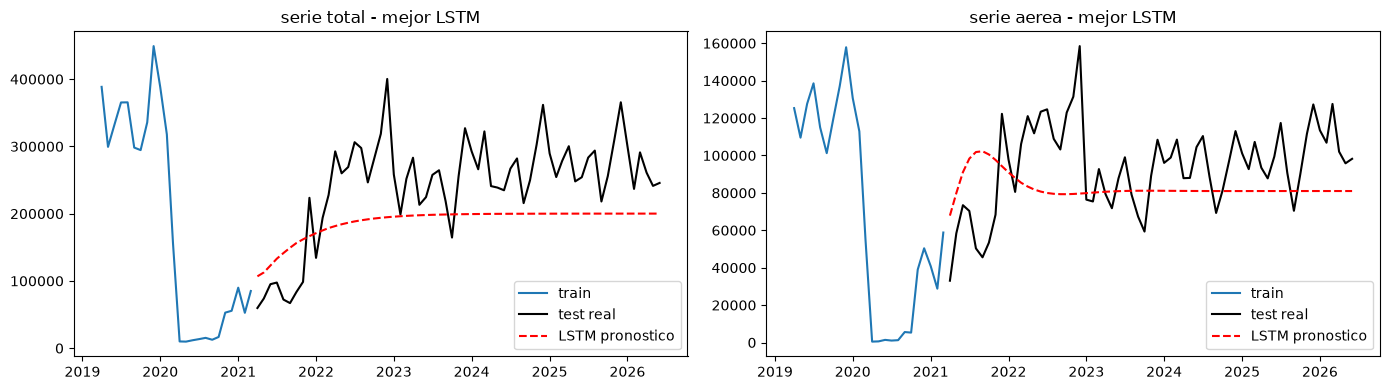

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (nombre, (train, test)) in zip(axes, series.items()):
    best = mejores[nombre]
    clave = (nombre, (int(best.lookback), int(best.hidden), int(best.layers)))
    pred = predicciones[clave]
    ax.plot(train.index[-24:], train.values[-24:], label="train")
    ax.plot(test.index, test.values, label="test real", color="black")
    ax.plot(test.index, pred, label="LSTM pronostico", color="red", ls="--")
    ax.set_title(f"serie {nombre} - mejor LSTM")
    ax.legend()
plt.tight_layout()
plt.show()

## Notas del avance

- Se entrenaron 5 configuraciones de LSTM por serie (10 en total) variando ventana, neuronas y capas.
- El pronóstico es recursivo sobre todo el test, que arranca en plena recuperación pospandemia, así
  que el error acumulado es esperable.
- Pendiente para la entrega final: comparar el mejor LSTM contra el mejor SARIMA del laboratorio 1,
  y agregar las características de catch22.